# Tópicos Especiais em Sistema Computacionais II - 2026.1
## **Projeto 05 - Redes MLP**
Autores: José Cláudio Alves Sobrinho e Ingridy Duarte Costa



## INTRODUÇÃO E CONTEXTO
A segurança de redes de computadores é um dos desafios centrais da infraestrutura digital moderna. Ataques como negação de serviço (DoS), varredura de portas (Probe) e acesso remoto não autorizado (R2L) causam prejuízos bilionários anualmente e comprometem desde sistemas corporativos até infraestruturas críticas de energia, saúde e comunicações. Sistemas de Detecção de Intrusão (IDS — Intrusion Detection Systems) são a principal linha de defesa ativa contra essas ameaças, e a automação dessa detecção por meio de aprendizado de máquina representa a fronteira atual da área.

As características de um ataque DoS se misturam às do tráfego legítimo em regiões do espaço de atributos que nenhuma linha reta consegue separar adequadamente. Assim sendo, uma rede Perceptron não é capaz de solucionar esse problema. Assim sendo, o Perceptron Multicamadas (MLP — Multilayer Perceptron), com suas camadas ocultas e funções de ativação não-lineares, supera essa limitação, tornando-se uma escolha natural para este tipo de problema.

Neste projeto, você é convidado a construir e treinar uma rede MLP utilizando o PyTorch para classificar conexões de rede como normais ou ataques, a partir de atributos extraídos de pacotes de rede.

##CONJUNTO DE DADOS

O projeto utiliza o dataset NSL-KDD (https://www.kaggle.com/datasets/hassan06/nslkdd), disponibilizado pelo Canadian Institute for Cybersecurity da Universidade de New Brunswick. O NSL-KDD é uma versão refinada do histórico KDD Cup 1999.

O conjunto disponibiliza dois arquivos: KDDTrain+.txt (125.973 amostras) e KDDTest+.txt (22.544 amostras). Cada registro representa uma conexão de rede e possui 41 atributos divididos em três grupos:

    (i) básicos — duração, protocolo (protocol_type), serviço (service), flag de estado da conexão (flag), bytes transferidos etc.;

    (ii) de conteúdo — número de tentativas de login com falha, acesso a arquivos sensíveis, comandos executados em sessões shell etc.;

    (iii) de tráfego — estatísticas das últimas conexões ao mesmo host e ao mesmo serviço, como taxa de erros SYN e taxa de conexões rejeitadas.

Dos 41 atributos, 38 são numéricos e 3 são categóricos (protocol_type, service e flag).

O rótulo original possui 23 tipos de ataque agrupados em 4 categorias (DoS, Probe, R2L, U2R) além da classe normal; neste projeto, o problema será tratado como classificação binária: 0 para conexão normal e 1 para qualquer tipo de ataque.

#1. Preparação dos dados: carregue os arquivos KDDTrain+.txt e KDDTest+.txt com o pandas, atribuindo nomes às colunas a seguinte lista de rótulos:

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

#As duas últimas colunas refere-se à saída (tipo de ataque e nível de dificuldade, mas essa última deve ser descartada). Aplique one-hot encoding nos três atributos categóricos (protocol_type, service, flag). Em seguida, binarize o rótulo (normal $\to$ 0; qualquer ataque $\to$ 1) e normalize todos os atributos numéricos com Z-score usando apenas as estatísticas do conjunto de treino.

In [ ]:
# 1. Instalação e Importação de dependências
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# --- DOWNLOAD DOS DADOS ---
# Utilizando a instrução fornecida
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Path to dataset files:", path)

# Localizando os arquivos específicos dentro do diretório baixado
train_path = os.path.join(path, "KDDTrain+.txt")
test_path = os.path.join(path, "KDDTest+.txt")

# --- PREPARAÇÃO DOS DADOS (Instrução 1 da image_9555e0.png) ---

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Carregando os arquivos com pandas
train_df = pd.read_csv(train_path, names=col_names, header=None)
test_df = pd.read_csv(test_path, names=col_names, header=None)

# Descartando a última coluna (difficulty_level)
train_df.drop('difficulty_level', axis=1, inplace=True)
test_df.drop('difficulty_level', axis=1, inplace=True)

# Binarização do rótulo: normal -> 0; qualquer ataque -> 1
train_df['attack_type'] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack_type'] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

# One-hot encoding nos atributos categóricos
categorical_cols = ['protocol_type', 'service', 'flag']
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Separando os rótulos e alinhando as colunas (importante para o One-Hot)
train_labels = train_df.pop('attack_type')
test_labels = test_df.pop('attack_type')
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# Normalização Z-score usando estatísticas do treino
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

# Conversão para tensores PyTorch
X_train = torch.tensor(train_df.values.astype(np.float32))
y_train = torch.tensor(train_labels.values.astype(np.float32)).unsqueeze(1)
X_test = torch.tensor(test_df.values.astype(np.float32))
y_test = torch.tensor(test_labels.values.astype(np.float32)).unsqueeze(1)

# DataLoader com mini-batches de 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)


Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd


#2. Implementação da MLP em PyTorch: crie uma classe MLP herdando de nn.Module. A função de perda deve ser BCEWithLogitsLoss. Implemente o método forward e instancie o modelo, o otimizador Adam e a função de perda. Encapsule os dados em TensorDataset e utilize um DataLoader com mini-batches de tamanho 256.

In [ ]:

# --- IMPLEMENTAÇÃO DA MLP (Instrução 2 da image_9555e0.png) ---

class NetMLP(nn.Module): # Herdando de nn.Module
    def __init__(self, input_size):
        super(NetMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x): # Implementando método forward
        return self.network(x)

# Instanciando modelo, otimizador Adam e perda BCEWithLogitsLoss
model = NetMLP(X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

print("Pronto! Dados preparados e modelo instanciado.")

Pronto! Dados preparados e modelo instanciado.


#3. Treinamento e monitoramento: treine a MLP por 50 épocas registrando a loss de treino a cada época. Reserve 20% do conjunto de treino como validação (sem embaralhamento após a divisão) e registre também a loss de validação. Ao final, plote as duas curvas na mesma figura. A escolha topológica da rede (número de neurônios por camada oculta, número de camadas ocultas e função de ativação) é de sua responsabilidade. Para isso, recomenda-se testar várias topologias de rede, verificando-se o desempenho no conjunto de validação. Verifique a necessidade de parada antecipada durante o processo de treinamento. Atenção: para o neurônio da camada de saída, não utilize função de ativação, pois será usada a função de perda BCEWithLogitsLoss.

Iniciando treinamento por 50 épocas...
Época 5/50 | Train Loss: 0.0161 | Val Loss: 0.0155
Época 10/50 | Train Loss: 0.0122 | Val Loss: 0.0152
Época 15/50 | Train Loss: 0.0104 | Val Loss: 0.0109
Época 20/50 | Train Loss: 0.0096 | Val Loss: 0.0170
Época 25/50 | Train Loss: 0.0081 | Val Loss: 0.0145
Época 30/50 | Train Loss: 0.0076 | Val Loss: 0.0169
Época 35/50 | Train Loss: 0.0068 | Val Loss: 0.0133
Época 40/50 | Train Loss: 0.0064 | Val Loss: 0.0167
Época 45/50 | Train Loss: 0.0060 | Val Loss: 0.0146
Época 50/50 | Train Loss: 0.0056 | Val Loss: 0.0170


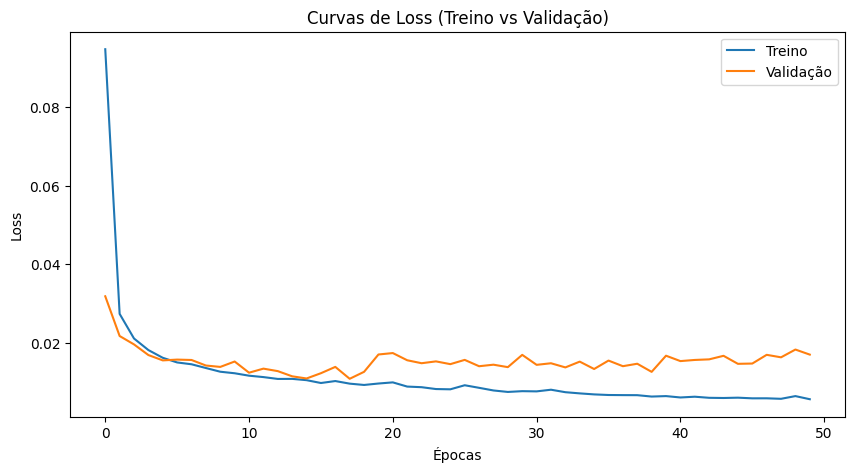

In [ ]:
# Divisão de 20% para validação (sem embaralhamento após a divisão)
val_size = int(0.2 * len(X_train))
train_size = len(X_train) - val_size

X_train_final, X_val = X_train[:train_size], X_train[train_size:]
y_train_final, y_val = y_train[:train_size], y_train[train_size:]

# Novos DataLoaders
train_loader_final = DataLoader(TensorDataset(X_train_final, y_train_final), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)

# Configurações de Treino
epochs = 50
train_losses = []
val_losses = []

print("Iniciando treinamento por 50 épocas...")

for epoch in range(epochs):
    # Fase de Treino
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader_final:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    # Fase de Validação
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X_val, batch_y_val in val_loader:
            val_outputs = model(batch_X_val)
            v_loss = criterion(val_outputs, batch_y_val)
            running_val_loss += v_loss.item()

    # Registro das losses médias
    train_losses.append(running_train_loss / len(train_loader_final))
    val_losses.append(running_val_loss / len(val_loader))

    if (epoch + 1) % 5 == 0:
        print(f"Época {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# Plotagem das curvas de Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title('Curvas de Loss (Treino vs Validação)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

#4. Avaliação final: utilizando a arquitetura de melhor desempenho na validação, avalie o modelo no conjunto de teste KDDTest+.txt. Aplique um limiar de 0,5 sobre a saída da sigmoide para obter os rótulos preditos e gere a matriz de confusão. Calcule e reporte acurácia, precisão, recall e F1-score. Em um sistema de detecção de intrusão em produção, qual tipo de erro é mais crítico: um falso negativo (ataque classificado como normal) ou um falso positivo (conexão normal classificada como ataque)? Como essa escolha afeta a definição do limiar de decisão?


--- Resultados no KDDTest+ ---
Acurácia:  0.7681
Precisão:  0.9200
Recall:     0.6490
F1-Score:   0.7611


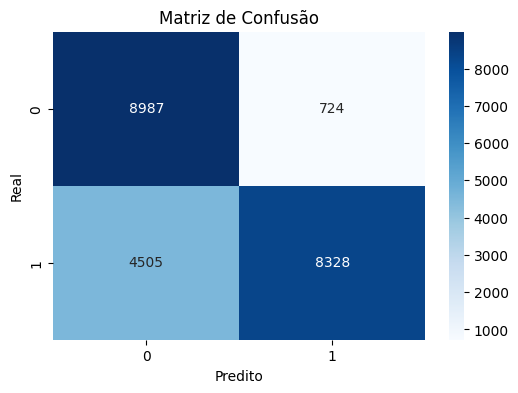

In [ ]:
model.eval()
with torch.no_grad():
    # Previsão no conjunto de teste KDDTest+
    test_outputs = model(X_test)
    # Aplicando a sigmoide e limiar de 0,5
    probabilities = torch.sigmoid(test_outputs)
    y_pred = (probabilities >= 0.5).float().numpy()

# Cálculo das métricas
y_true = y_test.numpy()
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n--- Resultados no KDDTest+ ---")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-Score:   {f1:.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

O Falso Negativo (deixar um ataque passar) é muito mais perigoso.


*   Falso Negativo (4.505 casos): É um ataque real que o sistema ignorou. Isso pode causar invasões e perda de dados.
*   Falso Positivo (724 casos): É um alarme falso. Causa trabalho extra para a equipe, mas não deixa a empresa em risco.


O que fazer com o Limiar (Threshold)?

Para tornar o sistema mais seguro, precisamos ajustar o "nível de suspeita" do modelo:



*   Ajuste: Devemos diminuir o limiar (ex: de 0,5 para 0,3).
*   Efeito: O modelo fica mais "paranoico". Ele detecta mais ataques (aumenta o Recall, que hoje é de 0,6490), mas acaba gerando mais alarmes falsos (diminui a Precisão).
    